# Day 5 · Notebook 1 — Machine learning meets the heart ❤️
### ML Bootcamp · Day 5 of 5

**Bioinstrumentation** = measuring signals from the body. The most famous one is the **ECG** (electrocardiogram): the heart's electrical activity.

In this notebook you will:
1. Load a **real ECG** from the MIT-BIH Arrhythmia Database (a hospital recording used by researchers since 1980) *(Part 1)*
2. **Clean** it with filters and remove 50 Hz mains noise *(Part 2)*
3. **Detect every heartbeat** and compute the heart rate *(Part 3)*
4. Train models to tell **normal from abnormal heartbeats** *(Part 4)*

> No GPU needed. Run cells in order with **Shift + Enter**. 🧠 = think about it, ✍️ = exercise (solutions at the end).
>
> ⚠️ This is for learning only — never use a classroom model to make medical decisions.

In [1]:
!pip install -q wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import wfdb
from scipy.signal import butter, filtfilt, iirnotch, find_peaks
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["font.size"] = 12
print("Ready!")

Ready!


---
## Part 1 · A real hospital ECG
Record **100** of the MIT-BIH database: a 30-minute recording, sampled **360 times per second**, with every heartbeat labelled by two cardiologists.

In [3]:
base = "https://raw.githubusercontent.com/MIT-LCP/wfdb-python/main/sample-data/"
for ext in ["hea", "dat", "atr"]:
    urllib.request.urlretrieve(base + "100." + ext, "100." + ext)

record = wfdb.rdrecord("100")          # the signal
ann = wfdb.rdann("100", "atr")         # the doctors' labels

fs = record.fs                          # sampling rate
ecg = record.p_signal[:, 0]            # channel 0 = lead MLII, in millivolts
print("Sampling rate:", fs, "samples per second")
print("Channels:", record.sig_name)
print("Length:", len(ecg), "samples =", round(len(ecg) / fs / 60, 1), "minutes")

Sampling rate: 360 samples per second
Channels: ['MLII', 'V5']
Length: 650000 samples = 30.1 minutes


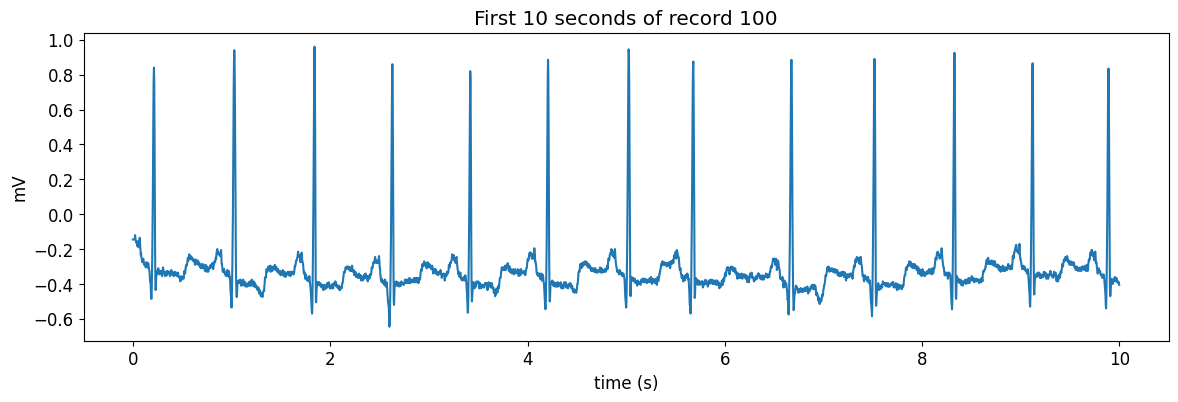

In [4]:
t = np.arange(len(ecg)) / fs            # time in seconds
plt.plot(t[:10 * fs], ecg[:10 * fs])
plt.xlabel("time (s)"); plt.ylabel("mV"); plt.title("First 10 seconds of record 100")
plt.show()

🧠 Each spike is one heartbeat. The tall spike is the **R wave** (part of the **QRS complex**, when the big chambers of the heart squeeze). Before it is the small **P wave**, after it the rounder **T wave**.

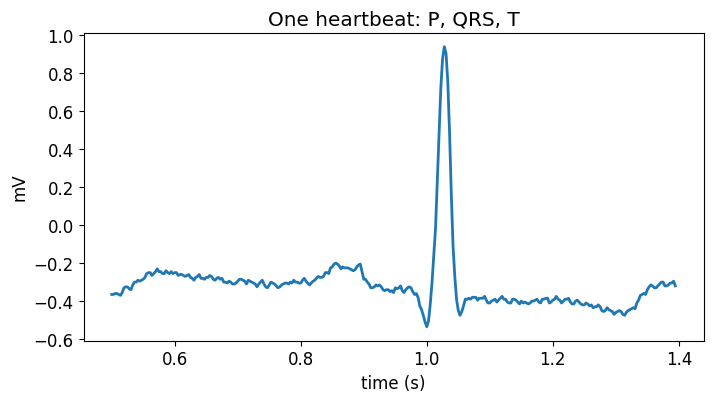

In [5]:
# Zoom in on one beat
plt.figure(figsize=(8, 4))
seg = slice(int(0.5 * fs), int(1.4 * fs))
plt.plot(t[seg], ecg[seg], linewidth=2)
plt.xlabel("time (s)"); plt.ylabel("mV"); plt.title("One heartbeat: P, QRS, T")
plt.show()

In [6]:
# What did the cardiologists label? N = normal, A = atrial premature beat, V = ventricular premature beat
import collections
print(collections.Counter(ann.symbol))

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


---
## Part 2 · Cleaning the signal (filters)
Real ECGs are noisy:
- **Baseline wander** — slow drift from breathing and body movement (below ~0.5 Hz)
- **Mains hum** — **50 Hz** from the power lines (Nigeria uses 50 Hz; the USA 60 Hz)
- **Muscle noise** — fast wiggles (above ~40 Hz)

A **band-pass filter** keeps only 0.5–40 Hz, where the heart's information is.
Let's first **add** 50 Hz noise on purpose, then remove it with a **notch filter**.

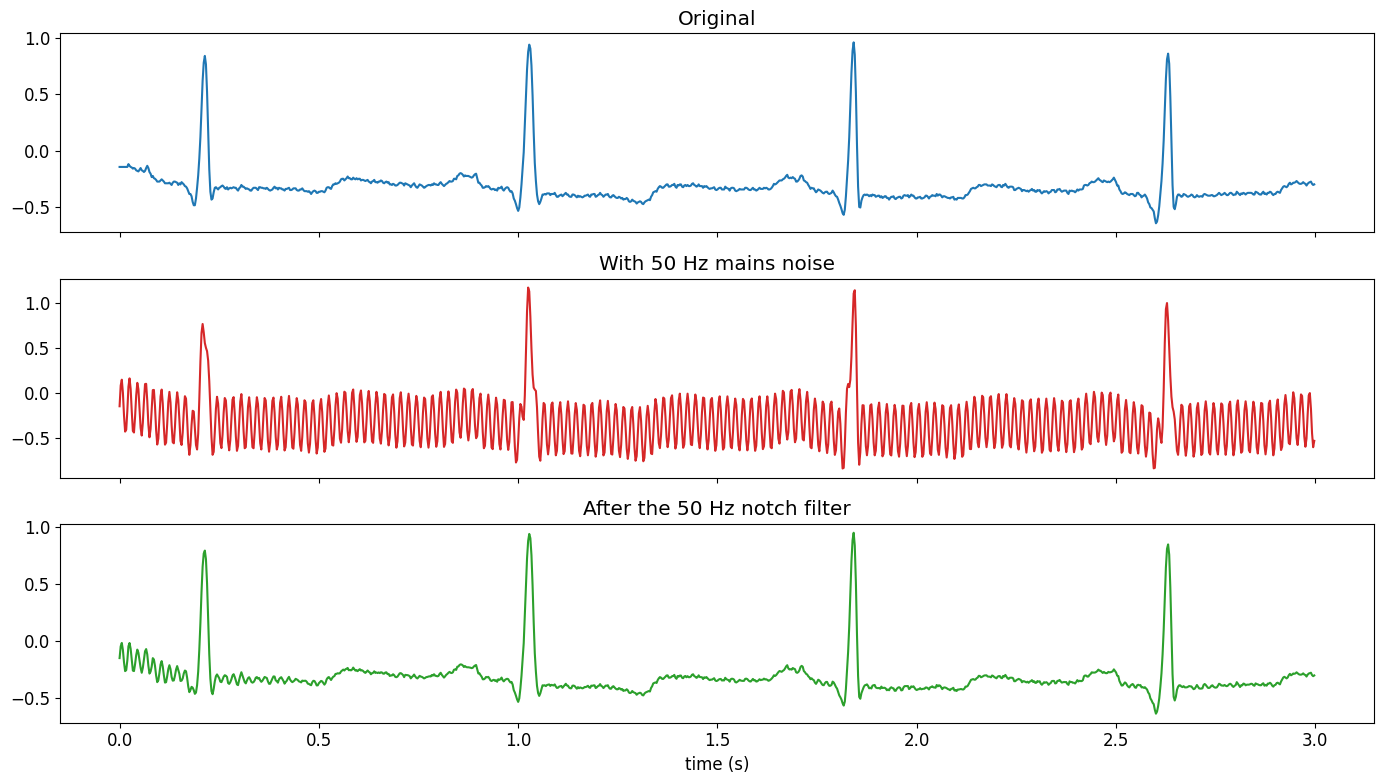

Average error after cleaning: 0.0036 mV


In [7]:
noisy = ecg + 0.3 * np.sin(2 * np.pi * 50 * t)      # add mains hum

b, a = iirnotch(w0=50, Q=30, fs=fs)                # notch filter: removes exactly 50 Hz
cleaned = filtfilt(b, a, noisy)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
seg = slice(0, 3 * fs)
axes[0].plot(t[seg], ecg[seg]); axes[0].set_title("Original")
axes[1].plot(t[seg], noisy[seg], color="tab:red"); axes[1].set_title("With 50 Hz mains noise")
axes[2].plot(t[seg], cleaned[seg], color="tab:green"); axes[2].set_title("After the 50 Hz notch filter")
axes[2].set_xlabel("time (s)"); plt.tight_layout(); plt.show()
print("Average error after cleaning:", round(np.abs(cleaned - ecg)[1000:-1000].mean(), 4), "mV")

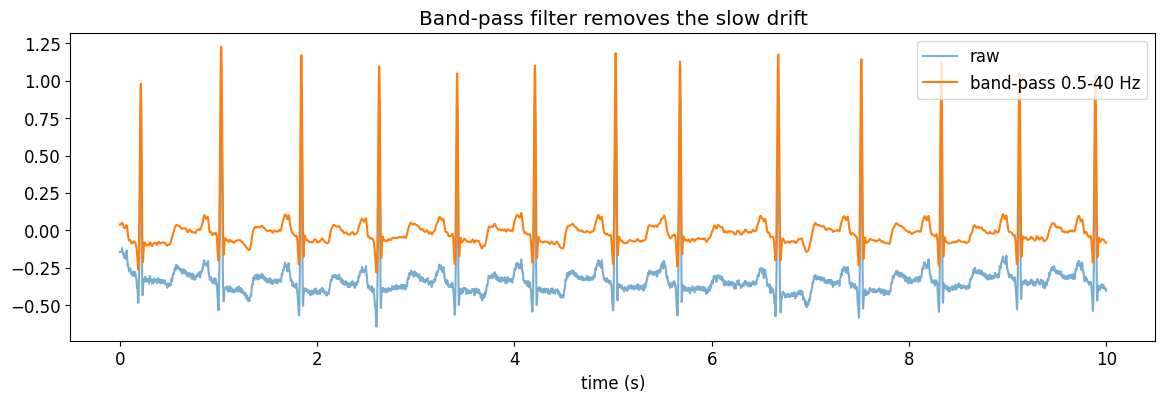

In [8]:
b, a = butter(3, [0.5, 40], btype="band", fs=fs)   # band-pass 0.5-40 Hz
ecg_f = filtfilt(b, a, ecg)

seg = slice(0, 10 * fs)
plt.plot(t[seg], ecg[seg], alpha=0.6, label="raw")
plt.plot(t[seg], ecg_f[seg], label="band-pass 0.5-40 Hz")
plt.legend(); plt.xlabel("time (s)"); plt.title("Band-pass filter removes the slow drift"); plt.show()

✍️ **Exercise 1:** add slow "breathing" drift: `drift = 0.5 * np.sin(2 * np.pi * 0.2 * t)`. Add it to `ecg`, then show that the band-pass filter removes it.

---
## Part 3 · Find every heartbeat → heart rate
The R peaks are the tallest points. `find_peaks` finds them: taller than 0.5 mV and at least 0.25 s apart (no heart beats faster than 240 per minute).

Heartbeats found: 2273


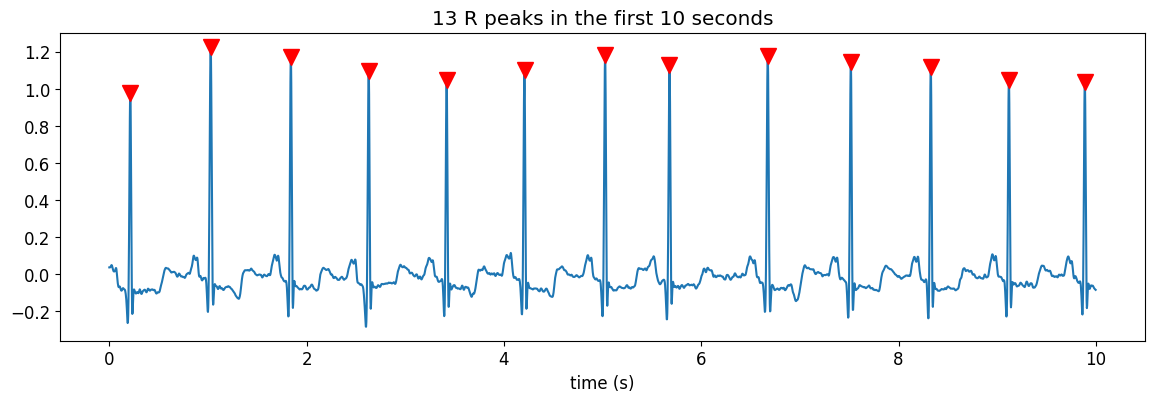

In [9]:
peaks, _ = find_peaks(ecg_f, height=0.5, distance=int(0.25 * fs))
print("Heartbeats found:", len(peaks))

seg_peaks = peaks[peaks < 10 * fs]
plt.plot(t[:10 * fs], ecg_f[:10 * fs])
plt.plot(t[seg_peaks], ecg_f[seg_peaks], "rv", markersize=12)
plt.title(f"{len(seg_peaks)} R peaks in the first 10 seconds"); plt.xlabel("time (s)"); plt.show()

### How good is our detector?
Compare with the cardiologists' labels. A detected peak counts as correct if it is within 50 ms of a labelled beat.

In [10]:
beat_symbols = set("NLRAaJSVFejE/fQ")
true_beats = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym in beat_symbols])

matched = sum(np.min(np.abs(true_beats - p)) < 0.05 * fs for p in peaks)
print("Real beats (doctors):", len(true_beats))
print("Correctly found:     ", matched)
print("Missed:              ", len(true_beats) - matched)
print("False alarms:        ", len(peaks) - matched)

Real beats (doctors): 2273
Correctly found:      2272
Missed:               1
False alarms:         1


Average heart rate: 75.8 bpm   (min 58, max 115)
Heart rate variability (SDNN): 48 ms


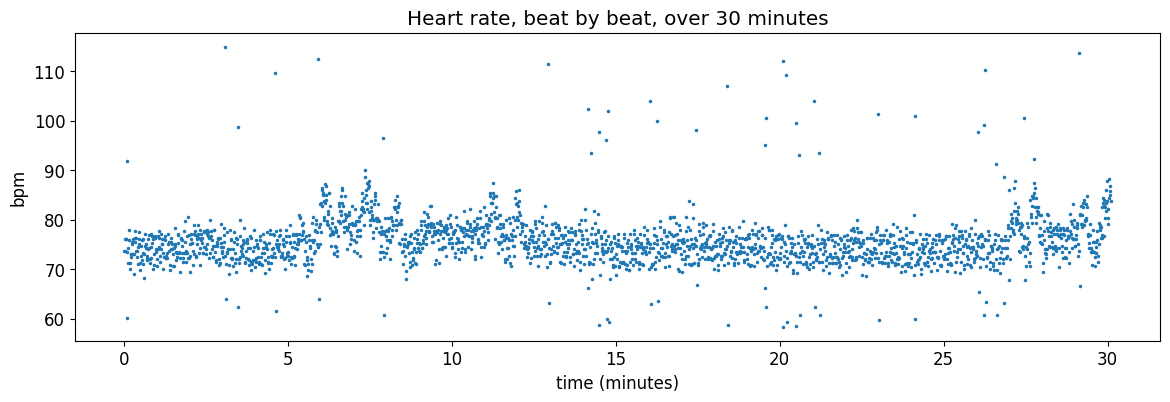

In [11]:
rr = np.diff(peaks) / fs            # time between beats (seconds)
hr = 60 / rr                        # beats per minute

print(f"Average heart rate: {hr.mean():.1f} bpm   (min {hr.min():.0f}, max {hr.max():.0f})")
print(f"Heart rate variability (SDNN): {rr.std() * 1000:.0f} ms")

minutes = peaks[1:] / fs / 60
plt.plot(minutes, hr, ".", markersize=3)
plt.xlabel("time (minutes)"); plt.ylabel("bpm"); plt.title("Heart rate, beat by beat, over 30 minutes")
plt.show()

🧠 A few beats jump up to ~115 bpm: those are the **premature beats** (A) the doctors labelled — they come too early. Classic signal processing (filter + peak finding) already does a great job. Now let's use **machine learning** to judge the *shape* of each beat.

---
## Part 4 · Normal or abnormal? Train a classifier
**ECG5000**: 4,998 single heartbeats from a patient with heart failure, each cut to **140 samples**, labelled normal or abnormal.

In [12]:
import pandas as pd

# ECG5000: 4,998 heartbeats, 140 samples each. Last column: 1 = normal, 0 = abnormal.
# Same file as TensorFlow's official tutorial; if Google's link is blocked we use a GitHub copy.
urls = ["http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv",
        "https://raw.githubusercontent.com/kanesp/ECG_Anomaly-Detection/master/data/ecg.csv"]
for url in urls:
    try:
        df = pd.read_csv(url, header=None)
        print("Loaded from", url)
        break
    except Exception as e:
        print("Could not load", url, "- trying the next link")

X = df.iloc[:, :140].values.astype("float32")
y = (df.iloc[:, 140] == 0).astype(int).values      # we flip it: 1 = ABNORMAL (the thing we want to catch)
print("Beats:", X.shape, "  abnormal:", y.sum(), "  normal:", (y == 0).sum())

Loaded from http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv
Beats: (4998, 140)   abnormal: 2079   normal: 2919


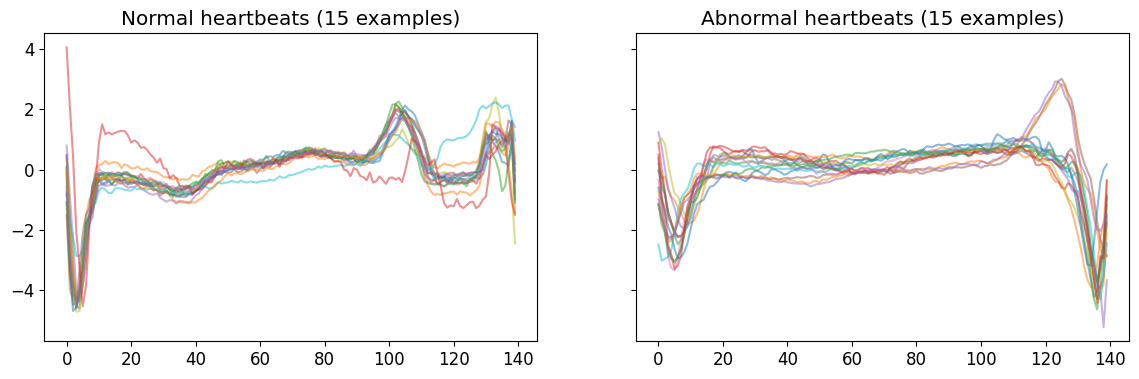

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, label, name in zip(axes, [0, 1], ["Normal", "Abnormal"]):
    for beat in X[y == label][:15]:
        ax.plot(beat, alpha=0.5)
    ax.set_title(f"{name} heartbeats (15 examples)")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", len(X_train), " Test:", len(X_test))

results = {}
for name, model in [("Logistic regression", LogisticRegression(max_iter=2000)),
                    ("Random forest", RandomForestClassifier(n_estimators=200, random_state=42))]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = model
    print(f"{name:20s} accuracy {accuracy_score(y_test, pred):.1%}   abnormal beats caught (recall) {recall_score(y_test, pred):.1%}")

Train: 3998  Test: 1000
Logistic regression  accuracy 99.3%   abnormal beats caught (recall) 98.6%
Random forest        accuracy 99.5%   abnormal beats caught (recall) 98.8%


🧠 Why do we care most about **recall** here? A missed abnormal beat (false negative) is worse than a false alarm.

### A 1-D CNN
On Day 4, CNNs slid 2-D filters over images. For a signal we slide **1-D filters** along time — they learn shapes like "a wide QRS" or "a missing P wave".

In [15]:
import keras
from keras import layers
keras.utils.set_random_seed(42)

cnn = keras.Sequential([
    keras.Input(shape=(140, 1)),
    layers.Conv1D(16, 7, activation="relu"),
    layers.MaxPooling1D(4),
    layers.Conv1D(32, 5, activation="relu"),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),      # probability of ABNORMAL
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
print("Weights:", cnn.count_params())
history = cnn.fit(X_train[..., None], y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

pred = (cnn.predict(X_test[..., None], verbose=0)[:, 0] > 0.5).astype(int)
print(f"1-D CNN              accuracy {accuracy_score(y_test, pred):.1%}   recall {recall_score(y_test, pred):.1%}")
print("Confusion matrix [[TN FP] [FN TP]]:\n", confusion_matrix(y_test, pred))

Weights: 17121
1-D CNN              accuracy 99.3%   recall 98.8%
Confusion matrix [[TN FP] [FN TP]]:
 [[582   2]
 [  5 411]]


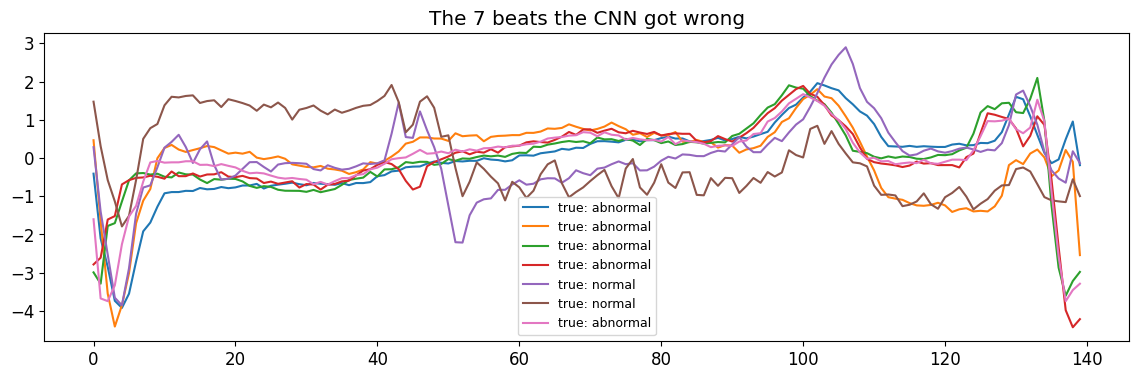

In [16]:
# Look at the beats the CNN got wrong
wrong = np.where(pred != y_test)[0]
plt.figure(figsize=(14, 4))
for i in wrong:
    plt.plot(X_test[i], label=f"true: {'abnormal' if y_test[i] else 'normal'}")
plt.title(f"The {len(wrong)} beats the CNN got wrong"); plt.legend(fontsize=9); plt.show()

🧠 All three models score about **99%**. On this clean, one-patient dataset even logistic regression is excellent — remember Day 3: *try simple first*.
But a real device needs a model that works for **everyone**, with noise and movement — that's where bigger datasets and CNNs matter.

In **Notebook 2** we shrink this CNN so it fits on a **$5 ESP32 chip**.

---
## ✅ Summary
- ECG = the heart's electrical signal; P, QRS, T waves; 360 samples per second here.
- Filters remove noise: band-pass 0.5–40 Hz, notch at 50 Hz.
- Peak finding found 2,272 of 2,273 beats → heart rate and HRV.
- ML classifies beat shapes: ~99% on ECG5000. Recall matters most in medicine.

---
## Solutions

In [ ]:
# Exercise 1
drift = 0.5 * np.sin(2 * np.pi * 0.2 * t)
wandering = ecg + drift
fixed = filtfilt(b, a, wandering)          # b, a = the band-pass filter from Part 2
seg = slice(0, 10 * fs)
plt.plot(t[seg], wandering[seg], label="with breathing drift")
plt.plot(t[seg], fixed[seg], label="after band-pass")
plt.legend(); plt.show()